<a href="https://colab.research.google.com/github/Edgar-Avila/008-machine-learning-clustering/blob/main/008_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clustering Jerárquico

## 1. Clustering "20 Newsgroups Dataset"

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

# Subconjunto de categorías
categories = ['sci.med', 'sci.space', 'rec.autos', 'rec.sport.baseball']
newsgroups = fetch_20newsgroups(subset='train', categories=categories, remove=('headers', 'footers', 'quotes'))

# TF-IDF para vectorizar
vectorizer = TfidfVectorizer(max_features=500, stop_words='english')
X = vectorizer.fit_transform(newsgroups.data).toarray()
y_true = newsgroups.target

print(f"Dimensiones de la matriz de características: {X.shape}")

Dimensiones de la matriz de características: (2378, 500)


In [28]:
# Prueba con Linkage 'ward'
clustering_ward = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels_ward = clustering_ward.fit_predict(X)
silhouette_ward = silhouette_score(X, labels_ward)

# Prueba con Linkage 'complete'
clustering_complete = AgglomerativeClustering(n_clusters=4, linkage='complete')
labels_complete = clustering_complete.fit_predict(X)
silhouette_complete = silhouette_score(X, labels_complete)

print(f"Silhouette ward: {silhouette_ward:.4f}")
print(f"Silhouette complete: {silhouette_complete:.4f}")

Silhouette ward: 0.0313
Silhouette complete: 0.0124


Ward obtiene un silhouette superior y grupos mejor definidos en representaciones TF-IDF comparado con complete.

## 2. Segmentación de clientes con datos sintéticos


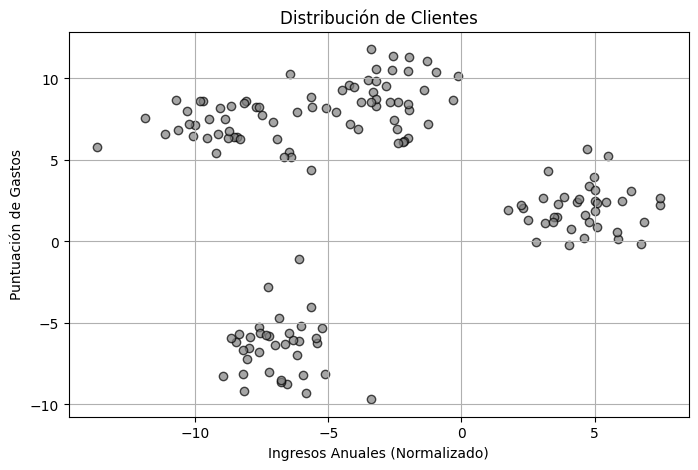

In [29]:
from sklearn.datasets import make_blobs
import pandas as pd
from scipy.cluster.hierarchy import dendrogram, linkage

X_customers, y_customers = make_blobs(n_samples=150, centers=4, n_features=2, random_state=42, cluster_std=1.5)

# Visualización de los datos sintéticos
plt.figure(figsize=(8, 5))
plt.scatter(X_customers[:, 0], X_customers[:, 1], c='gray', edgecolors='k', alpha=0.7)
plt.title("Distribución de Clientes")
plt.xlabel("Ingresos Anuales (Normalizado)")
plt.ylabel("Puntuación de Gastos")
plt.grid(True)
plt.show()

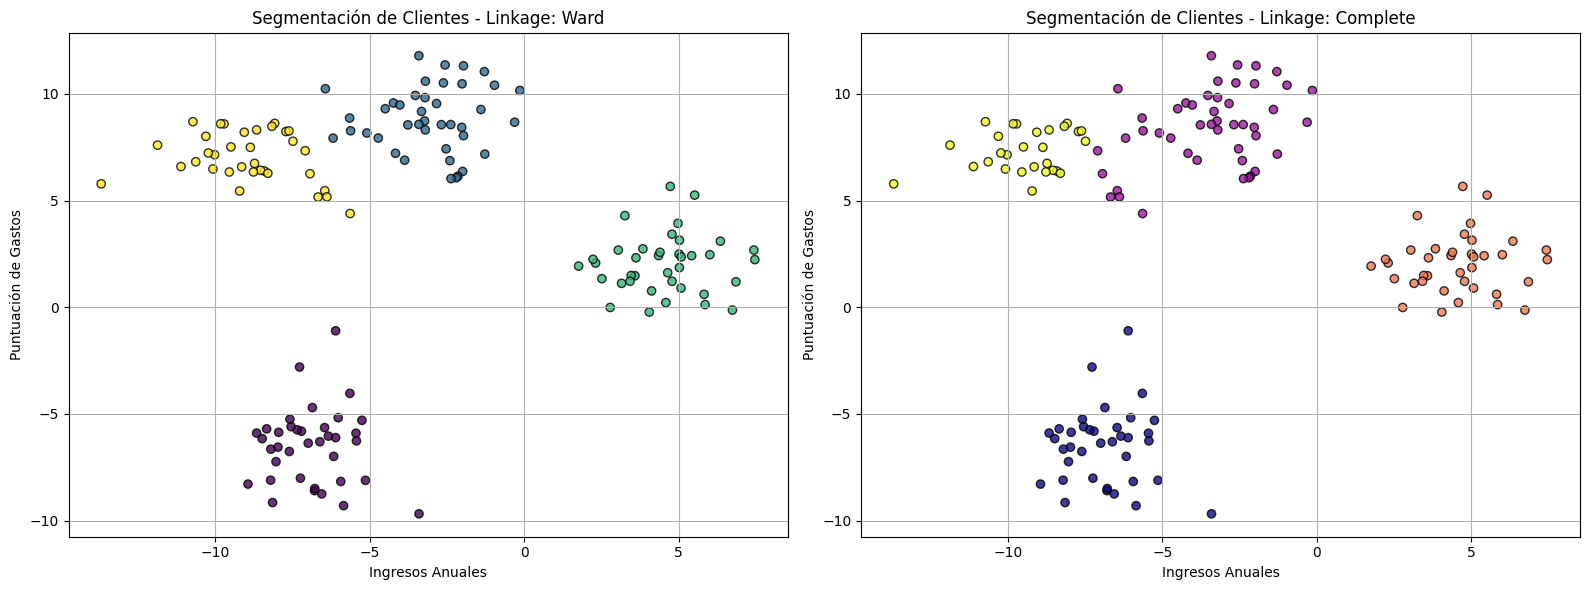

In [30]:
# Clustering 'ward'
cluster_ward = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels_ward_cust = cluster_ward.fit_predict(X_customers)

# Clustering 'complete'
cluster_complete = AgglomerativeClustering(n_clusters=4, linkage='complete')
labels_complete_cust = cluster_complete.fit_predict(X_customers)

# Grafico
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].scatter(X_customers[:, 0], X_customers[:, 1], c=labels_ward_cust, cmap='viridis', edgecolors='k', alpha=0.8)
axes[0].set_title("Segmentación de Clientes - Linkage: Ward")
axes[0].set_xlabel("Ingresos Anuales")
axes[0].set_ylabel("Puntuación de Gastos")
axes[0].grid(True)
axes[1].scatter(X_customers[:, 0], X_customers[:, 1], c=labels_complete_cust, cmap='plasma', edgecolors='k', alpha=0.8)
axes[1].set_title("Segmentación de Clientes - Linkage: Complete")
axes[1].set_xlabel("Ingresos Anuales")
axes[1].set_ylabel("Puntuación de Gastos")
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 3. Segmentación de imagenes

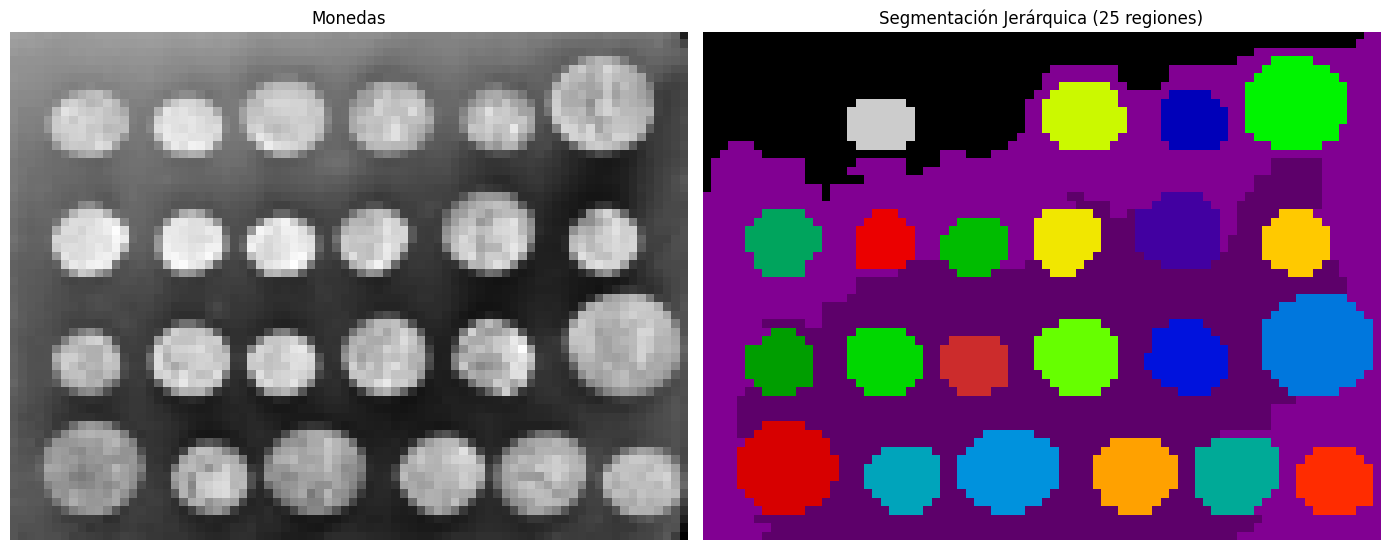

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.feature_extraction.image import grid_to_graph
from skimage.data import coins
from skimage.transform import resize

# Cargar la imagen
original_coins = coins()
img_resized = resize(original_coins, (60, 80))
X_img = img_resized.reshape(-1, 1)

# Clustering jerárquico con enlace 'ward'
connectivity = grid_to_graph(*img_resized.shape)
n_clusters = 25 # Monedas y el fondo
ward_real = AgglomerativeClustering(n_clusters=n_clusters, connectivity=connectivity, linkage='ward')
ward_real.fit(X_img)
segmented_labels = ward_real.labels_.reshape(img_resized.shape)

# Graficar los resultados
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(img_resized, cmap='gray')
axes[0].set_title("Monedas")
axes[0].axis('off')

axes[1].imshow(segmented_labels, cmap='nipy_spectral')
axes[1].set_title(f"Segmentación Jerárquica ({n_clusters} regiones)")
axes[1].axis('off')

plt.tight_layout()
plt.show()